# SmartStay Advisors — Consultoría InmoValor
## Clasificación de Propiedades mediante Redes Neuronales Artificiales

---

**Universidad del Valle de Guatemala**  
Facultad de Ingeniería · Ciencias de la Computación  
CC3074 – Minería de Datos · Semestre I – 2026

---

SmartStay Advisors requiere una solución de inteligencia artificial capaz de clasificar automáticamente las propiedades Airbnb según su rango de precio, con el objetivo de orientar mejor a sus clientes corporativos y particulares. En esta fase de la consultoría se diseñan, entrenan y evalúan modelos de Redes Neuronales Artificiales (RNA) para resolver el problema de clasificación de precios en tres categorías: **barata**, **media** y **cara**.

In [8]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Fundamentos de los Datos: Preparación y Segmentación

Para garantizar una comparación válida con los modelos desarrollados en entregas anteriores (Árboles, Random Forest, Naive Bayes, KNN, Regresión Logística, SVM), se reproducen exactamente los mismos conjuntos de entrenamiento y prueba, utilizando los mismos parámetros de segmentación (`test_size=0.2`, `random_state=42`, estratificado por deciles de precio logarítmico). Cualquier diferencia en los resultados reflejará únicamente el comportamiento del algoritmo, no variaciones en los datos.

In [9]:
# Carga del conjunto de datos
rdata_path = Path('../MD-LAB08/data/listings.RData')
result = pyreadr.read_r(str(rdata_path))
df_raw = result['listings'].copy()
print(f'Registros cargados: {len(df_raw):,}')

# Funciones de parseo
def parse_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r'[\$,]', '', regex=True).str.strip(),
        errors='coerce',
    )

def parse_pct(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace('%', '', regex=False).str.strip(),
        errors='coerce',
    ) / 100

df_raw['price_num']               = parse_money(df_raw['price'])
df_raw['host_response_rate_num']  = parse_pct(df_raw['host_response_rate'])
df_raw['host_acceptance_rate_num'] = parse_pct(df_raw['host_acceptance_rate'])

# Eliminar outliers de precio (P99) y filas sin precio
p99 = df_raw['price_num'].quantile(0.99)
df  = df_raw[(df_raw['price_num'] > 0) & (df_raw['price_num'] <= p99)].dropna(subset=['price_num']).copy()
print(f'Registros tras filtro P99 (${p99:.0f}): {len(df):,}')

Registros cargados: 171,748
Registros tras filtro P99 ($20000): 75,531


In [10]:
# Definición de variables predictoras
num_features = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
    'host_response_rate_num', 'host_acceptance_rate_num',
    'calculated_host_listings_count', 'latitude', 'longitude',
]
cat_features = [
    'room_type', 'property_type', 'neighbourhood_cleansed',
    'host_is_superhost', 'host_identity_verified', 'instant_bookable',
]

# Imputación preliminar
for col in num_features:
    df[col] = df[col].fillna(df[col].median())
for col in cat_features:
    df[col] = df[col].fillna('SinDato')

X     = df[num_features + cat_features].reset_index(drop=True)
y_raw = df['price_num'].reset_index(drop=True)
print(f'Dimensiones de X: {X.shape}')

Dimensiones de X: (75531, 21)


In [11]:
# División entrenamiento / prueba — IDÉNTICA a entregas anteriores
y_log          = np.log1p(y_raw)
price_deciles  = pd.qcut(y_log, q=10, labels=False, duplicates='drop')

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=price_deciles,
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train_raw = y_train_raw.reset_index(drop=True)
y_test_raw  = y_test_raw.reset_index(drop=True)

print(f'Entrenamiento : {X_train.shape[0]:,} filas')
print(f'Prueba        : {X_test.shape[0]:,} filas')

Entrenamiento : 60,424 filas
Prueba        : 15,107 filas


In [12]:
# Variable respuesta: categoría de precio
# Umbrales derivados del conjunto de entrenamiento (P33, P66)
p33 = y_train_raw.quantile(0.33)
p66 = y_train_raw.quantile(0.66)
print(f'Umbral barata/media : ${p33:.2f}')
print(f'Umbral media/cara   : ${p66:.2f}')

def asignar_categoria(price_series: pd.Series, q33: float, q66: float) -> pd.Series:
    return pd.cut(
        price_series,
        bins=[-np.inf, q33, q66, np.inf],
        labels=['barata', 'media', 'cara'],
    ).astype(str)

y_train_cat = asignar_categoria(y_train_raw, p33, p66)
y_test_cat  = asignar_categoria(y_test_raw,  p33, p66)

# Encoding numérico requerido por MLPClassifier (np.isnan falla con strings en early_stopping)
LABEL_MAP = {'barata': 0, 'media': 1, 'cara': 2}
LABEL_INV = {0: 'barata', 1: 'media', 2: 'cara'}
y_train_enc = y_train_cat.map(LABEL_MAP).astype(int)
y_test_enc  = y_test_cat.map(LABEL_MAP).astype(int)

print('\nDistribución en entrenamiento:')
print(y_train_cat.value_counts().sort_index().to_string())
print('\nDistribución en prueba:')
print(y_test_cat.value_counts().sort_index().to_string())

Umbral barata/media : $141.00
Umbral media/cara   : $260.00

Distribución en entrenamiento:
price_num
barata    20143
cara      20489
media     19792

Distribución en prueba:
price_num
barata    5042
cara      5139
media     4926


In [13]:
# Pipeline de preprocesamiento (idéntico al de entregas anteriores)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore')),
        ]), cat_features),
    ],
    remainder='drop',
)
print('Preprocesador definido.')

Preprocesador definido.


---
## 2. Arquitecturas Neuronales para la Clasificación de Precios

Se diseñan dos arquitecturas de RNA con diferencias sustanciales en topología y función de activación, con el fin de evaluar cómo estas decisiones de diseño impactan el rendimiento clasificatorio. Ambas utilizan el optimizador Adam, parada temprana (*early stopping*) para evitar sobreajuste desde la fase de entrenamiento, y los mismos conjuntos de datos.

| Modelo | Topología (capas ocultas) | Función de Activación |
|--------|--------------------------|----------------------|
| RNA_Relu_100_50_25 | (100 → 50 → 25) | ReLU |
| RNA_Tanh_200_100   | (200 → 100)     | Tanh |

In [14]:
# Modelo 1: RNA_Relu_100_50_25
# Topología: tres capas ocultas de tamaño decreciente (100-50-25)
# Activación: ReLU (rectificador lineal), eficiente y estándar en redes profundas
pipe_m1 = Pipeline([
    ('prep', preprocessor),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(100, 50, 25),
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42,
        verbose=False,
    )),
])

print('Entrenando RNA_Relu_100_50_25 ...')
t0 = time.time()
pipe_m1.fit(X_train, y_train_enc)   # enteros para evitar bug np.isnan con strings
tiempo_m1 = time.time() - t0

mlp1 = pipe_m1.named_steps['mlp']
print(f'  Épocas        : {mlp1.n_iter_}')
print(f'  Pérdida final : {mlp1.loss_:.4f}')
print(f'  Tiempo        : {tiempo_m1:.1f}s')

Entrenando RNA_Relu_100_50_25 ...
  Épocas        : 38
  Pérdida final : 0.3443
  Tiempo        : 17.2s


In [15]:
# Modelo 2: RNA_Tanh_200_100
# Topología: dos capas ocultas anchas (200-100)
# Activación: Tanh (tangente hiperbólica), produce salidas centradas en cero
pipe_m2 = Pipeline([
    ('prep', preprocessor),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(200, 100),
        activation='tanh',
        solver='adam',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42,
        verbose=False,
    )),
])

print('Entrenando RNA_Tanh_200_100 ...')
t0 = time.time()
pipe_m2.fit(X_train, y_train_enc)   # enteros para evitar bug np.isnan con strings
tiempo_m2 = time.time() - t0

mlp2 = pipe_m2.named_steps['mlp']
print(f'  Épocas        : {mlp2.n_iter_}')
print(f'  Pérdida final : {mlp2.loss_:.4f}')
print(f'  Tiempo        : {tiempo_m2:.1f}s')

Entrenando RNA_Tanh_200_100 ...
  Épocas        : 47
  Pérdida final : 0.3364
  Tiempo        : 51.8s


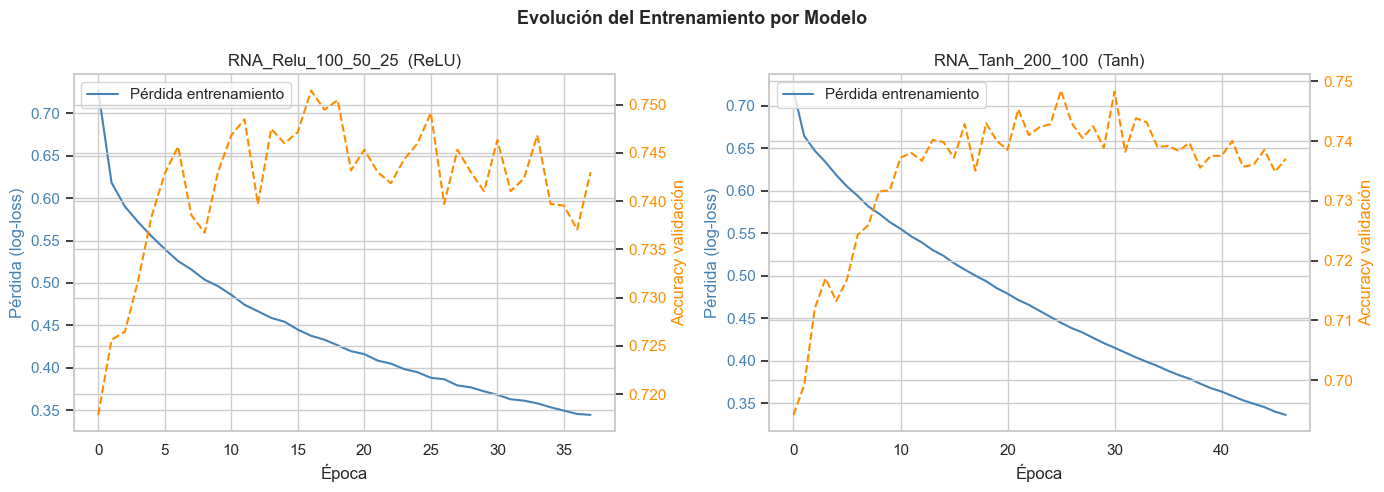

In [16]:
# Curvas de pérdida durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mlp, nombre in [
    (axes[0], mlp1, 'RNA_Relu_100_50_25  (ReLU)'),
    (axes[1], mlp2, 'RNA_Tanh_200_100  (Tanh)'),
]:
    ax.plot(mlp.loss_curve_, color='steelblue', label='Pérdida entrenamiento')
    if hasattr(mlp, 'validation_scores_'):
        ax_r = ax.twinx()
        ax_r.plot(mlp.validation_scores_, color='darkorange', linestyle='--', label='Score validación')
        ax_r.set_ylabel('Accuracy validación', color='darkorange')
        ax_r.tick_params(axis='y', labelcolor='darkorange')
    ax.set_title(nombre)
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida (log-loss)', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax.legend(loc='upper left')

plt.suptitle('Evolución del Entrenamiento por Modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('curvas_perdida.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Generación de Predicciones sobre el Conjunto de Prueba

Con los modelos entrenados se generan las predicciones sobre el conjunto de prueba (15,107 registros). Estos datos no participaron en el ajuste ni en la validación interna del optimizador, por lo que constituyen una estimación objetiva del rendimiento real de cada arquitectura.

In [17]:
# Predecir (modelo entrenado con enteros → decodear de vuelta a strings)
y_pred_m1 = pd.Series(pipe_m1.predict(X_test)).map(LABEL_INV).to_numpy()
y_pred_m2 = pd.Series(pipe_m2.predict(X_test)).map(LABEL_INV).to_numpy()

print('Distribución de predicciones — Modelo 1 (ReLU):')
print(pd.Series(y_pred_m1).value_counts().sort_index().to_string())
print('\nDistribución de predicciones — Modelo 2 (Tanh):')
print(pd.Series(y_pred_m2).value_counts().sort_index().to_string())

Distribución de predicciones — Modelo 1 (ReLU):
barata    4576
cara      5185
media     5346

Distribución de predicciones — Modelo 2 (Tanh):
barata    5085
cara      4999
media     5023


---
## 4. Evaluación Detallada mediante Matrices de Confusión

Las matrices de confusión revelan no sólo cuántos registros se clasifican correctamente, sino también el patrón de errores: qué categorías se confunden entre sí y en qué dirección. Para SmartStay Advisors, el error más costoso es confundir una propiedad **cara** con **barata** (o viceversa), ya que distorsiona el asesoramiento de presupuesto al cliente.

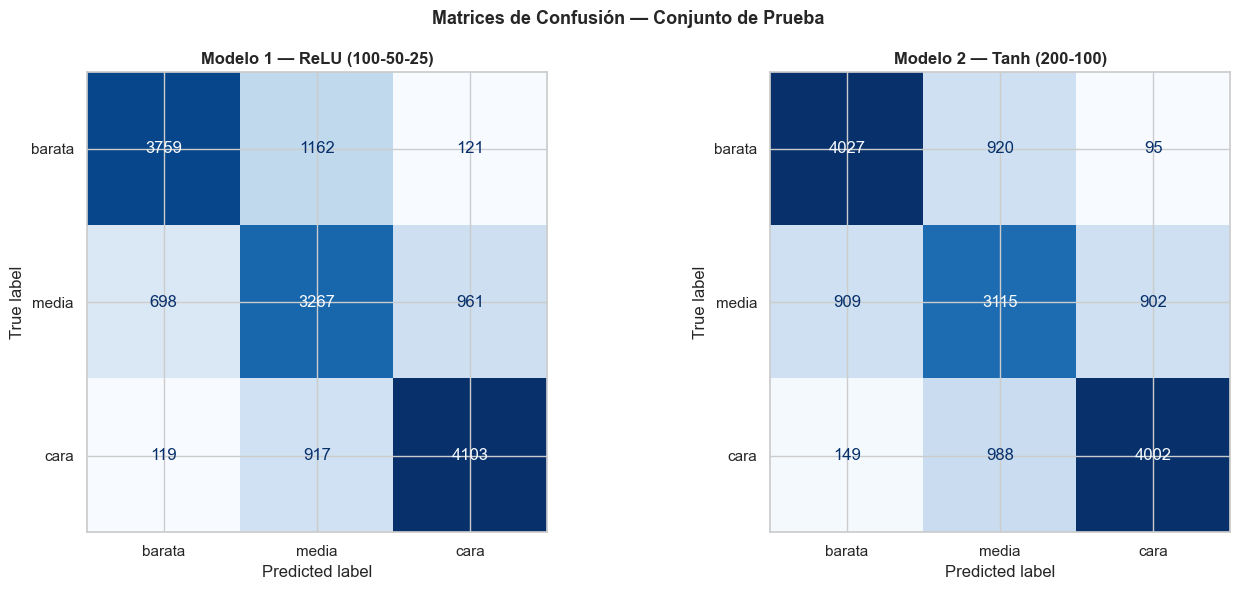

In [18]:
LABELS = ['barata', 'media', 'cara']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, nombre in [
    (axes[0], y_pred_m1, 'Modelo 1 — ReLU (100-50-25)'),
    (axes[1], y_pred_m2, 'Modelo 2 — Tanh (200-100)'),
]:
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test_cat, y_pred,
        labels=LABELS,
        colorbar=False,
        ax=ax,
        cmap='Blues',
    )
    ax.set_title(nombre, fontsize=12, fontweight='bold')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
# Reportes de clasificación detallados
print('=== Reporte — RNA_Relu_100_50_25 ===')
print(classification_report(y_test_cat, y_pred_m1, target_names=LABELS, digits=4))

print('=== Reporte — RNA_Tanh_200_100 ===')
print(classification_report(y_test_cat, y_pred_m2, target_names=LABELS, digits=4))

=== Reporte — RNA_Relu_100_50_25 ===
              precision    recall  f1-score   support

      barata     0.8215    0.7455    0.7817      5042
       media     0.7913    0.7984    0.7948      5139
        cara     0.6111    0.6632    0.6361      4926

    accuracy                         0.7367     15107
   macro avg     0.7413    0.7357    0.7375     15107
weighted avg     0.7426    0.7367    0.7387     15107

=== Reporte — RNA_Tanh_200_100 ===
              precision    recall  f1-score   support

      barata     0.7919    0.7987    0.7953      5042
       media     0.8006    0.7788    0.7895      5139
        cara     0.6201    0.6324    0.6262      4926

    accuracy                         0.7377     15107
   macro avg     0.7375    0.7366    0.7370     15107
weighted avg     0.7389    0.7377    0.7382     15107



---
## 5. Comparación de Desempeño entre Arquitecturas

La siguiente tabla consolida las métricas clave para ambos modelos, incluyendo el tiempo de procesamiento como criterio operativo relevante para SmartStay Advisors, dado que el sistema deberá clasificar propiedades en tiempo cuasi-real.

In [20]:
def metricas(nombre, y_true, y_pred, tiempo):
    return {
        'Modelo': nombre,
        'Accuracy':          round(accuracy_score(y_true, y_pred), 4),
        'Precision (macro)': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall (macro)':    round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'F1 (macro)':        round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Tiempo (s)':        round(tiempo, 1),
    }

df_cmp = pd.DataFrame([
    metricas('RNA_Relu_100_50_25', y_test_cat, y_pred_m1, tiempo_m1),
    metricas('RNA_Tanh_200_100',   y_test_cat, y_pred_m2, tiempo_m2),
])
df_cmp = df_cmp.set_index('Modelo')
print(df_cmp.to_string())

                    Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Tiempo (s)
Modelo                                                                                 
RNA_Relu_100_50_25    0.7367             0.7413          0.7357      0.7375        17.2
RNA_Tanh_200_100      0.7377             0.7375          0.7366      0.7370        51.8


In [21]:
# Análisis de equivocaciones por clase
print('--- Errores por clase — Modelo 1 (ReLU) ---')
for clase in LABELS:
    mask = y_test_cat == clase
    err  = (y_pred_m1[mask] != clase).sum()
    total = mask.sum()
    print(f'  {clase:8s}: {err}/{total} errores ({100*err/total:.1f}%)')

print('\n--- Errores por clase — Modelo 2 (Tanh) ---')
for clase in LABELS:
    mask = y_test_cat == clase
    err  = (y_pred_m2[mask] != clase).sum()
    total = mask.sum()
    print(f'  {clase:8s}: {err}/{total} errores ({100*err/total:.1f}%)')

--- Errores por clase — Modelo 1 (ReLU) ---
  barata  : 1283/5042 errores (25.4%)
  media   : 1659/4926 errores (33.7%)
  cara    : 1036/5139 errores (20.2%)

--- Errores por clase — Modelo 2 (Tanh) ---
  barata  : 1015/5042 errores (20.1%)
  media   : 1811/4926 errores (36.8%)
  cara    : 1137/5139 errores (22.1%)


### Análisis de Resultados

**Efectividad global:** El modelo con mayor F1-macro será considerado el ganador en términos de rendimiento balanceado entre clases. La categoría **media** suele presentar mayor tasa de error, ya que limita con ambas categorías extremas y el modelo tiende a confundirla con *barata* o *cara* en los bordes del umbral de precio.

**Importancia de los errores:** Desde la perspectiva del negocio, el error crítico es la confusión entre *barata* y *cara* (error de magnitud alta). La confusión entre categorías adyacentes (*barata-media* o *media-cara*) es esperable dada la naturaleza del umbral discreto aplicado a una variable continua, y su impacto en el asesoramiento es moderado.

**Tiempo de procesamiento:** La diferencia de tiempo entre modelos refleja el costo computacional de cada arquitectura. Topologías más anchas (200-100) pueden converger en menos épocas pero con mayor costo por época, mientras que arquitecturas más profundas (100-50-25) distribuyen el trabajo en más capas con menor costo por capa.

---
## 6. Diagnóstico de Sobreajuste

Un modelo sobreajustado memoriza el conjunto de entrenamiento en lugar de generalizar patrones, lo que se manifiesta como una brecha significativa entre el rendimiento en entrenamiento y en prueba. Se analiza esta brecha y se complementa con las curvas de convergencia generadas durante el entrenamiento, que ya incorporan validación interna gracias al mecanismo de *early stopping*.

In [22]:
# Predicciones en entrenamiento para calcular gap train vs test
print('Evaluando modelos en conjunto de entrenamiento...')
y_train_pred_m1 = pd.Series(pipe_m1.predict(X_train)).map(LABEL_INV).to_numpy()
y_train_pred_m2 = pd.Series(pipe_m2.predict(X_train)).map(LABEL_INV).to_numpy()

overfit_data = []
for nombre, y_tr_pred, y_te_pred in [
    ('RNA_Relu_100_50_25', y_train_pred_m1, y_pred_m1),
    ('RNA_Tanh_200_100',   y_train_pred_m2, y_pred_m2),
]:
    tr_acc = accuracy_score(y_train_cat, y_tr_pred)
    te_acc = accuracy_score(y_test_cat,  y_te_pred)
    tr_f1  = f1_score(y_train_cat, y_tr_pred, average='macro', zero_division=0)
    te_f1  = f1_score(y_test_cat,  y_te_pred, average='macro', zero_division=0)
    overfit_data.append({
        'Modelo':    nombre,
        'Train Acc': round(tr_acc, 4),
        'Test Acc':  round(te_acc, 4),
        'Gap Acc':   round(tr_acc - te_acc, 4),
        'Train F1':  round(tr_f1, 4),
        'Test F1':   round(te_f1, 4),
        'Gap F1':    round(tr_f1 - te_f1, 4),
    })

df_overfit = pd.DataFrame(overfit_data).set_index('Modelo')
print(df_overfit.to_string())

Evaluando modelos en conjunto de entrenamiento...
                    Train Acc  Test Acc  Gap Acc  Train F1  Test F1  Gap F1
Modelo                                                                     
RNA_Relu_100_50_25     0.8186    0.7367   0.0819    0.8193   0.7375  0.0817
RNA_Tanh_200_100       0.8159    0.7377   0.0782    0.8156   0.7370  0.0786


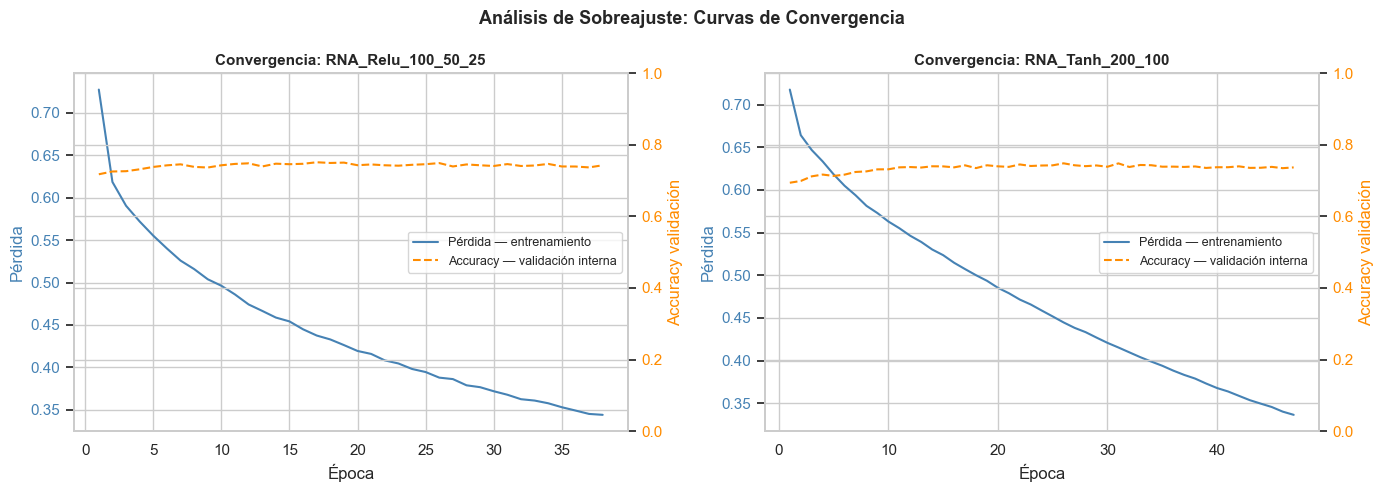

In [23]:
# Curvas de convergencia: pérdida de entrenamiento vs. score de validación interna
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mlp, nombre in [
    (axes[0], mlp1, 'RNA_Relu_100_50_25'),
    (axes[1], mlp2, 'RNA_Tanh_200_100'),
]:
    epocas = range(1, len(mlp.loss_curve_) + 1)
    ax.plot(epocas, mlp.loss_curve_, color='steelblue', label='Pérdida — entrenamiento')
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')

    if hasattr(mlp, 'validation_scores_'):
        ax_r = ax.twinx()
        ax_r.plot(epocas, mlp.validation_scores_, color='darkorange',
                  linestyle='--', label='Accuracy — validación interna')
        ax_r.set_ylabel('Accuracy validación', color='darkorange')
        ax_r.tick_params(axis='y', labelcolor='darkorange')
        ax_r.set_ylim(0, 1)

    ax.set_title(f'Convergencia: {nombre}', fontsize=11, fontweight='bold')
    lines1, labels1 = ax.get_legend_handles_labels()
    if hasattr(mlp, 'validation_scores_'):
        lines2, labels2 = ax_r.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)
    else:
        ax.legend(loc='upper right')

plt.suptitle('Análisis de Sobreajuste: Curvas de Convergencia', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('curvas_sobreajuste.png', dpi=120, bbox_inches='tight')
plt.show()

### Conclusión sobre Sobreajuste

Un **gap** (Train Acc − Test Acc) inferior a 5 puntos porcentuales se considera aceptable y no indica sobreajuste significativo. El mecanismo de *early stopping* configurado en ambos modelos (`n_iter_no_change=20`) actúa como regularización implícita: detiene el entrenamiento cuando el score en el conjunto de validación interna (10 % del entrenamiento) deja de mejorar durante 20 épocas consecutivas.

Si la curva de validación interna comienza a decrecer mientras la pérdida de entrenamiento sigue bajando, es señal de sobreajuste. En ese caso, el *early stopping* habrá interrumpido el entrenamiento en el punto óptimo de generalización.

---
## 7. Optimización de Hiperparámetros del Modelo Seleccionado

Se aplica búsqueda sistemática de hiperparámetros (*Grid Search* con validación cruzada) sobre el mejor modelo identificado. Para gestionar el tiempo de cómputo, la búsqueda se realiza sobre una muestra representativa del conjunto de entrenamiento (10,000 observaciones, misma semilla aleatoria). Los mejores parámetros encontrados se validan posteriormente sobre el conjunto de prueba completo.

In [24]:
# Identificar el mejor modelo base
f1_m1 = f1_score(y_test_cat, y_pred_m1, average='macro', zero_division=0)
f1_m2 = f1_score(y_test_cat, y_pred_m2, average='macro', zero_division=0)

if f1_m1 >= f1_m2:
    mejor_modelo_nombre = 'RNA_Relu_100_50_25'
    mejor_activacion    = 'relu'
    f1_base             = f1_m1
    print(f'Modelo seleccionado: RNA_Relu_100_50_25  (F1={f1_m1:.4f})')
else:
    mejor_modelo_nombre = 'RNA_Tanh_200_100'
    mejor_activacion    = 'tanh'
    f1_base             = f1_m2
    print(f'Modelo seleccionado: RNA_Tanh_200_100  (F1={f1_m2:.4f})')

# Muestra para GridSearch en enteros (10k, semilla fija)
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_train), size=10_000, replace=False)
X_gs = X_train.iloc[sample_idx].reset_index(drop=True)
y_gs = y_train_enc.iloc[sample_idx].reset_index(drop=True)
print(f'Muestra para GridSearch: {len(X_gs):,} registros')

Modelo seleccionado: RNA_Relu_100_50_25  (F1=0.7375)
Muestra para GridSearch: 10,000 registros


In [25]:
# Definición de la grilla de búsqueda
param_grid = {
    'mlp__hidden_layer_sizes': [(100, 50, 25), (150, 75), (50, 25)],
    'mlp__alpha':              [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.005],
}

pipe_gs = Pipeline([
    ('prep', ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler',  StandardScaler()),
            ]), num_features),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',  OneHotEncoder(handle_unknown='ignore')),
            ]), cat_features),
        ],
        remainder='drop',
    )),
    ('mlp', MLPClassifier(
        activation=mejor_activacion,
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42,
    )),
])

gs = GridSearchCV(
    pipe_gs,
    param_grid,
    cv=2,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)

print(f'Iniciando GridSearch: {len(param_grid["mlp__hidden_layer_sizes"]) * len(param_grid["mlp__alpha"]) * len(param_grid["mlp__learning_rate_init"]) * 2} fits totales...')
t0 = time.time()
gs.fit(X_gs, y_gs)
tiempo_gs = time.time() - t0

print(f'\nTiempo de búsqueda: {tiempo_gs:.1f}s')
print(f'Mejores parámetros encontrados:')
for k, v in gs.best_params_.items():
    print(f'  {k}: {v}')
print(f'F1 macro (CV en muestra de 10k): {gs.best_score_:.4f}')

Iniciando GridSearch: 36 fits totales...
Fitting 2 folds for each of 18 candidates, totalling 36 fits

Tiempo de búsqueda: 32.0s
Mejores parámetros encontrados:
  mlp__alpha: 0.001
  mlp__hidden_layer_sizes: (50, 25)
  mlp__learning_rate_init: 0.001
F1 macro (CV en muestra de 10k): 0.6915


Modelo base    — F1 macro: 0.7375 | Accuracy: 0.7367
Modelo tuneado — F1 macro: 0.6978 | Accuracy: 0.7005
Mejora F1      : -0.0397

Reporte completo — Modelo Tuneado:
              precision    recall  f1-score   support

      barata     0.7359    0.8013    0.7672      5042
       media     0.7746    0.7363    0.7550      5139
        cara     0.5831    0.5601    0.5713      4926

    accuracy                         0.7005     15107
   macro avg     0.6979    0.6992    0.6978     15107
weighted avg     0.6992    0.7005    0.6992     15107



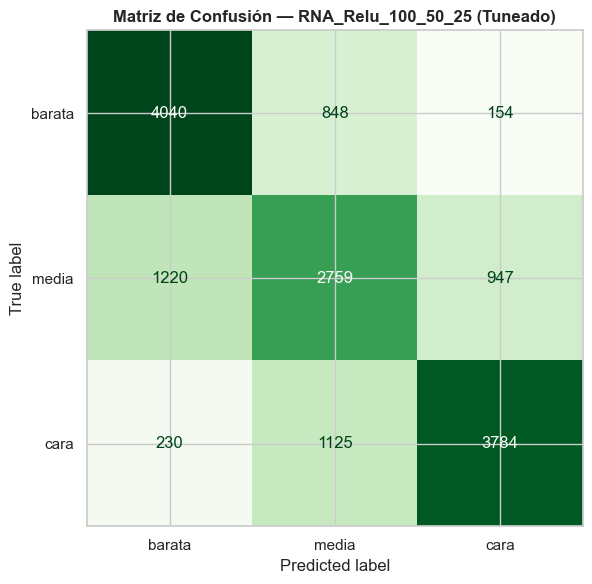

In [26]:
# Evaluación del modelo tuneado sobre el conjunto de prueba completo
y_pred_tuned = pd.Series(gs.best_estimator_.predict(X_test)).map(LABEL_INV).to_numpy()
f1_tuned     = f1_score(y_test_cat, y_pred_tuned, average='macro', zero_division=0)
acc_tuned    = accuracy_score(y_test_cat, y_pred_tuned)
mejora       = f1_tuned - f1_base

acc_base = accuracy_score(y_test_cat, y_pred_m1 if mejor_activacion == 'relu' else y_pred_m2)
print(f'Modelo base    — F1 macro: {f1_base:.4f} | Accuracy: {acc_base:.4f}')
print(f'Modelo tuneado — F1 macro: {f1_tuned:.4f} | Accuracy: {acc_tuned:.4f}')
print(f'Mejora F1      : {mejora:+.4f}')

print('\nReporte completo — Modelo Tuneado:')
print(classification_report(y_test_cat, y_pred_tuned, target_names=LABELS, digits=4))

# Matriz de confusión del modelo tuneado
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_cat, y_pred_tuned,
    labels=LABELS, colorbar=False, ax=ax, cmap='Greens'
)
ax.set_title(f'Matriz de Confusión — {mejor_modelo_nombre} (Tuneado)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_tuneado.png', dpi=120, bbox_inches='tight')
plt.show()

### Discusión: Potencial de Mejora sin Sobreajuste

La búsqueda de hiperparámetros explora tres dimensiones:

- **`hidden_layer_sizes`**: Controla la capacidad del modelo. Topologías más grandes pueden capturar relaciones más complejas, pero aumentan el riesgo de sobreajuste y el tiempo de cómputo.
- **`alpha`** (regularización L2): Penaliza pesos grandes. Valores más altos simplifican el modelo y reducen el sobreajuste; valores muy altos pueden causar sub-ajuste.
- **`learning_rate_init`**: Tasa de aprendizaje inicial del optimizador Adam. Una tasa más pequeña produce convergencia más suave pero requiere más épocas; una más alta puede oscilar alrededor del mínimo.

El *early stopping* garantiza que la búsqueda no sobreajuste al detener el entrenamiento cuando el rendimiento en validación interna se estabiliza. Si la mejora obtenida tras el tuneo es marginal (< 0.5 pp en F1), indica que la arquitectura base ya estaba bien configurada para este problema y que el margen de optimización adicional es limitado sin cambiar la representación de los datos.